<a href="https://colab.research.google.com/github/Werianin/shift-MLI-2026/blob/main/SHIFT-INTENSIVE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import StratifiedKFold, cross_val_score

In [2]:
np.random.seed(42)

In [3]:
df_train = pd.read_csv('/df_train_full.csv')
df_test = pd.read_csv('/X_test.csv')

In [4]:
def collapse_duplicates(df):
    # Группируем по телефону и берем первое НЕ пустое значение (first)
    df_collapsed = df.groupby('Телефон', as_index=False).first()
    return df_collapsed

In [5]:
def fill_nans(df):
    for col in df.columns:
        if df[col].isnull().any():
            if df[col].dtype == 'object':
                df[col] = df[col].fillna(df[col].mode()[0])
            else:
                df[col] = df[col].fillna(df[col].median())
    return df

In [6]:
def encode_categorical_features(df):
    le = LabelEncoder()
    for col in df.select_dtypes(include=['object']).columns:
        df[col] = le.fit_transform(df[col].astype(str))
    return df

In [7]:
def final_expert_preprocess(df):
    # 1. УДАЛЕНИЕ ЛИШНИХ
    to_drop = [
        'Год_рождения', 'Знак_зодиака',
        'Размер', 'Подписаны_документы',
        'Возраст', 'БылПростой', 'Телефон'
    ]
    df = df.drop(columns=to_drop)

    # 2. ЗАПОЛНЕНИЕ ПРОПУСКОВ
    df = fill_nans(df)

    # 3. ГРУППИРОВАНИЕ ГОРОДОВ
    df['Город'] = df['Город'].replace({'Bangalore': 'Big_City', 'New Delhi': 'Big_City'})

    # 4. ПОРЯДКОВОЕ КОДИРОВАНИЕ ОБРАЗОВАНИЯ
    # PHD -> Bachelor -> Masters
    edu_map = {'PHD': 0, 'Bachelors': 1, 'Masters': 2}
    df['Образование'] = df['Образование'].map(edu_map)

    # 5. КОДИРОВАНИЕ ОСТАЛЬНЫХ КАТЕГОРИЙ
    df = encode_categorical_features(df)

    return df

In [8]:
# ПОДГОТОВКА ДАННЫХ
df_train = collapse_duplicates(df_train)
df_train_final = final_expert_preprocess(df_train)
X_train_final = df_train_final.drop(columns=['Увольнение'])
y_train_final = df_train_final['Увольнение']
X_test_final = final_expert_preprocess(df_test)

# ОБУЧЕНИЕ СЛУЧАЙНОГО ЛЕСА
rf_model = RandomForestClassifier(
    n_estimators=60,
    max_depth=8,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

# Кросс-валидация
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = cross_val_score(rf_model, X_train_final, y_train_final, cv=skf)

print(f"Средняя точность леса: {cv_results.mean():.4f}")
print(f"Разброс: {cv_results.std():.4f}")

# Финальное обучение

rf_model.fit(X_train_final, y_train_final)

Средняя точность леса: 0.7768
Разброс: 0.0116


RandomForestClassifier(max_depth=8, min_samples_leaf=2, n_estimators=60,
                       n_jobs=-1, random_state=42)

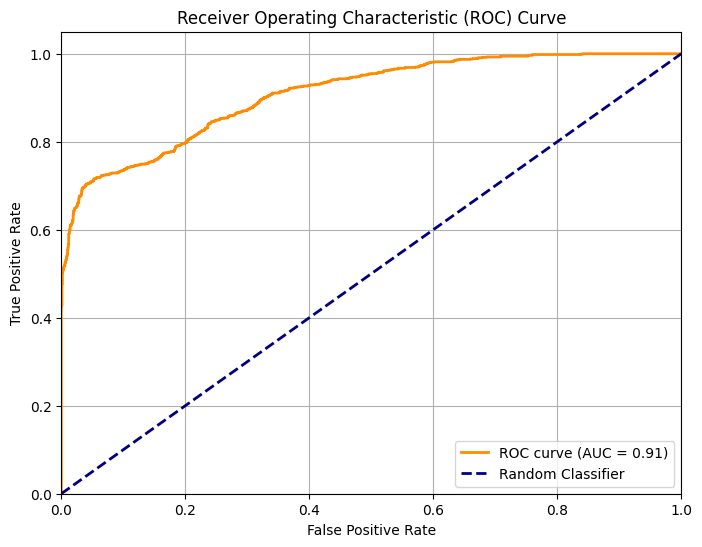

In [9]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# Get predicted probabilities for the training set
y_train_pred_proba = rf_model.predict_proba(X_train_final)[:, 1]

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_train_final, y_train_pred_proba)
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

In [10]:
predictions = rf_model.predict(X_test_final)
probabilities = rf_model.predict_proba(X_test_final)[:, 1]

In [11]:
answer = pd.DataFrame()
answer['proba'] = probabilities
answer.to_csv('/submission.csv', index=False)

In [12]:
import joblib

# Save the trained model
joblib.dump(rf_model, 'rf_model.joblib')
print("Model saved to 'rf_model.joblib'")

Model saved to 'rf_model.joblib'
